# Classification Part A — Gaussian Naive Bayes

## Overview
This notebook implements **Gaussian Naive Bayes (GaussianNB)** to predict customer review scores. It includes metric evaluation, confusion matrix, and a mandatory markdown discussion of the conditional independence assumption.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
data = np.load('classification_data.npz')
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

feature_names = pd.read_csv('classification_feature_names.csv', header=None)[0].to_numpy()
print(f"Loaded X_train: {X_train.shape}, X_test: {X_test.shape}")


Loaded X_train: (17044, 130), X_test: (4262, 130)


## 1. Model Fitting & Prediction


In [3]:
gnb_model = GaussianNB()
gnb_model.fit(X_train, y_train)

y_test_pred = gnb_model.predict(X_test)
y_test_proba = gnb_model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)
roc_auc = roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='weighted')

print(f"Accuracy         : {accuracy:.4f}")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall   : {recall:.4f}")
print(f"Weighted F1-Score : {f1:.4f}")
print(f"Weighted ROC-AUC  : {roc_auc:.4f}")


Accuracy         : 0.2482
Weighted Precision: 0.2836
Weighted Recall   : 0.2482
Weighted F1-Score : 0.1845
Weighted ROC-AUC  : 0.5823


## 2. Confusion Matrix & Classification Report


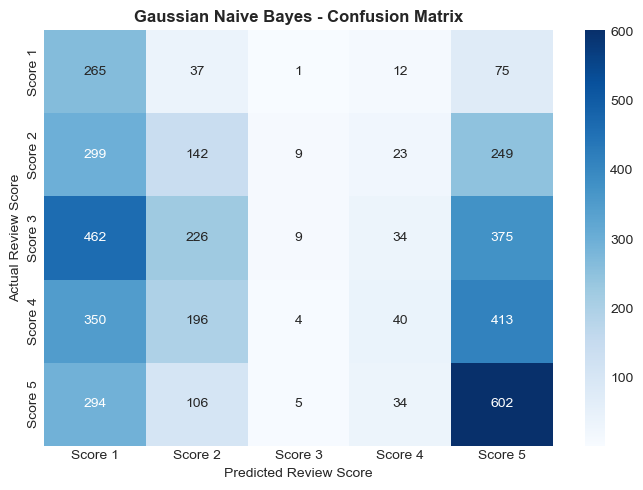

Classification Report:

              precision    recall  f1-score   support

     Score 1       0.16      0.68      0.26       390
     Score 2       0.20      0.20      0.20       722
     Score 3       0.32      0.01      0.02      1106
     Score 4       0.28      0.04      0.07      1003
     Score 5       0.35      0.58      0.44      1041

    accuracy                           0.25      4262
   macro avg       0.26      0.30      0.20      4262
weighted avg       0.28      0.25      0.18      4262



In [4]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Score 1', 'Score 2', 'Score 3', 'Score 4', 'Score 5'],
            yticklabels=['Score 1', 'Score 2', 'Score 3', 'Score 4', 'Score 5'])
plt.title("Gaussian Naive Bayes - Confusion Matrix", fontsize=12, fontweight='bold')
plt.xlabel("Predicted Review Score")
plt.ylabel("Actual Review Score")
plt.tight_layout()
plt.show()

print("Classification Report:\n")
print(classification_report(y_test, y_test_pred, target_names=['Score 1', 'Score 2', 'Score 3', 'Score 4', 'Score 5'], zero_division=0))


## 3. Mandatory Demonstration: Conditional Independence Assumption Discussion

> **Algorithm Note Requirement**: *Discuss conditional independence assumption*

### Theoretical Basis
Gaussian Naive Bayes applies Bayes' Theorem under the assumption that all input features $X_1, X_2, \dots, X_p$ are **conditionally independent** given the class label $Y$:
$$P(X_1, X_2, \dots, X_p \mid Y) = \prod_{i=1}^{p} P(X_i \mid Y)$$

### Violation in E-Commerce Data & Practical Impact
1. **Correlated Features**: In our e-commerce dataset, several features are inherently correlated (e.g., `total_cost = price + freight_value`, `comment_len` and `has_comment`, `customer_state` and `seller_state`).
2. **Impact on Probability Calibration**: Because Naive Bayes treats correlated features as independent evidence, it double-counts correlated signals, leading to overconfident class probabilities (probabilities pushed near 0 or 1).
3. **Robustness**: Despite violating independence, Gaussian Naive Bayes remains extremely fast to train and provides a competitive probabilistic baseline.


In [5]:
gnb_results = {
    "Model": "Gaussian Naive Bayes",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "Weighted F1": f1,
    "ROC-AUC": roc_auc
}
gnb_results


{'Model': 'Gaussian Naive Bayes',
 'Accuracy': 0.24824026278742375,
 'Precision': 0.28357199331808836,
 'Recall': 0.24824026278742375,
 'Weighted F1': 0.18450139066646573,
 'ROC-AUC': 0.5822862742841691}